

# Geospatial analysis of foreign-owned properties in England and Wales

In [ ]:
!pip install folium
import pandas as pd
import folium
from folium.plugins import HeatMap

In [ ]:
from geopy.geocoders import Nominatim

In [ ]:
raw_df = pd.read_csv('/content/raw_OCOD_FULL_2025_03.csv')
raw_df.head()

<ipython-input-8-184e2d5d7391>:1: DtypeWarning: Columns (24,28,30,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv('/content/raw_OCOD_FULL_2025_03.csv')


,Title Number,Tenure,Property Address,District,County,Region,Postcode,Multiple Address Indicator,Price Paid,Proprietor Name (1),...,Proprietor (3) Address (3),Proprietor Name (4),Company Registration No. (4),Proprietorship Category (4),Country Incorporated (4),Proprietor (4) Address (1),Proprietor (4) Address (2),Proprietor (4) Address (3),Date Proprietor Added,Additional Proprietor Indicator
0,YY110871,Leasehold,"6, Marshalls Court, Street Lane, Gildersome, M...",LEEDS,WEST YORKSHIRE,YORKS AND HUMBER,LS27 7GP,N,105000.0,POLESTAR LIMITED,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25-10-2018,N
1,YY112277,Freehold,"Park House, Dawsons Square, Pudsey (LS28 5EZ)",LEEDS,WEST YORKSHIRE,YORKS AND HUMBER,LS28 5EZ,N,NaN,L1 UK PROPERTY NOMINEE A1 PTY LIMITED,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21-11-2018,N
2,YY118306,Leasehold,"Apartment 9, Mabgate House, 53 Mabgate, Leeds ...",LEEDS,WEST YORKSHIRE,YORKS AND HUMBER,LS9 7DY,N,189995.0,PRESTON STAR HOLDINGS LIMITED,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12-03-2019,N
3,YY119352,Leasehold,"Flat 411, The Xchange, 6 Charles Street, Bradf...",BRADFORD,WEST YORKSHIRE,YORKS AND HUMBER,BD1 1HB,N,64082.0,ASH INTERNATIONAL INVESTMENT HOLDINGS LIMITED,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01-04-2019,N
4,YY119357,Leasehold,"Flat 509, The Xchange, 6 Charles Street, Bradf...",BRADFORD,WEST YORKSHIRE,YORKS AND HUMBER,BD1 1HB,N,65187.0,ASH INTERNATIONAL INVESTMENT HOLDINGS LIMITED,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01-04-2019,N


In [ ]:
raw_df.columns

Index(['Title Number', 'Tenure', 'Property Address', 'District', 'County',
       'Region', 'Postcode', 'Multiple Address Indicator', 'Price Paid',
       'Proprietor Name (1)', 'Company Registration No. (1)',
       'Proprietorship Category (1)', 'Country Incorporated (1)',
       'Proprietor (1) Address (1)', 'Proprietor (1) Address (2)',
       'Proprietor (1) Address (3)', 'Proprietor Name (2)',
       'Company Registration No. (2)', 'Proprietorship Category (2)',
       'Country Incorporated (2)', 'Proprietor (2) Address (1)',
       'Proprietor (2) Address (2)', 'Proprietor (2) Address (3)',
       'Proprietor Name (3)', 'Company Registration No. (3)',
       'Proprietorship Category (3)', 'Country Incorporated (3)',
       'Proprietor (3) Address (1)', 'Proprietor (3) Address (2)',
       'Proprietor (3) Address (3)', 'Proprietor Name (4)',
       'Company Registration No. (4)', 'Proprietorship Category (4)',
       'Country Incorporated (4)', 'Proprietor (4) Address (1)',
     

In [ ]:
# The most resonable data cleaning is to see the average of the price and also know if we to drop or fill
raw_df.describe()

,Price Paid,Proprietor (3) Address (3),Company Registration No. (4),Proprietor (4) Address (3)
count,3.369700e+04,0.0,0.0,0.0
mean,3.628322e+06,NaN,NaN,NaN
std,1.349871e+07,NaN,NaN,NaN
min,1.000000e+02,NaN,NaN,NaN
25%,1.977820e+05,NaN,NaN,NaN
50%,4.950000e+05,NaN,NaN,NaN
75%,1.587000e+06,NaN,NaN,NaN
max,4.485000e+08,NaN,NaN,NaN


In [ ]:
raw_df['Price Paid'].mean()

np.float64(3628321.5688340208)

In [ ]:
raw_df['Price Paid'].min()

100.0

In [ ]:
raw_df['Price Paid'].max()

448500000.0

In [ ]:
# I don't have have much data to make a better judgment so is safe to drop the nan using price paid
raw_df = raw_df.dropna(subset=['Price Paid'])
raw_df.isna().sum()

,0
Title Number,0
Tenure,0
Property Address,0
District,0
County,0
Region,0
Postcode,2570
Multiple Address Indicator,0
Price Paid,0
Proprietor Name (1),0


In [ ]:
# drop all columns that have more than 30000 empty row "nan"
raw_df = raw_df.dropna(thresh=30000, axis=1)
raw_df.isna().sum()

,0
Title Number,0
Tenure,0
Property Address,0
District,0
County,0
Region,0
Postcode,2570
Multiple Address Indicator,0
Price Paid,0
Proprietor Name (1),0


In [ ]:
# i am using the postcode to get the co-ordinate so i need it as clean as possible
raw_df = raw_df.dropna(subset=['Postcode'])
raw_df.isna().sum()

,0
Title Number,0
Tenure,0
Property Address,0
District,0
County,0
Region,0
Postcode,0
Multiple Address Indicator,0
Price Paid,0
Proprietor Name (1),0


In [ ]:
# Let check the date proprietor added column
raw_df['Date Proprietor Added'].value_counts()

,count
Date Proprietor Added,
28-05-2019,148
10-01-2024,114
08-04-2019,102
05-10-2017,100
21-12-2018,86
...,...
29-08-2012,1
21-11-2000,1
18-09-2001,1


In [ ]:
# Since i don't intend to perform any analysis on time series using this data i will also drop
raw_df = raw_df.drop(columns=['Date Proprietor Added'])


In [ ]:
raw_df.head()

,Title Number,Tenure,Property Address,District,County,Region,Postcode,Multiple Address Indicator,Price Paid,Proprietor Name (1),Proprietorship Category (1),Country Incorporated (1),Proprietor (1) Address (1),Additional Proprietor Indicator
0,YY110871,Leasehold,"6, Marshalls Court, Street Lane, Gildersome, M...",LEEDS,WEST YORKSHIRE,YORKS AND HUMBER,LS27 7GP,N,105000.0,POLESTAR LIMITED,Limited Company or Public Limited Company,ISLE OF MAN,"Ground Floor, Murdoch Chambers, South Quay, Do...",N
2,YY118306,Leasehold,"Apartment 9, Mabgate House, 53 Mabgate, Leeds ...",LEEDS,WEST YORKSHIRE,YORKS AND HUMBER,LS9 7DY,N,189995.0,PRESTON STAR HOLDINGS LIMITED,Limited Company or Public Limited Company,BRITISH VIRGIN ISLANDS,"Suite A 5/F Centre Mark II, 305-313 , Queen's ...",N
3,YY119352,Leasehold,"Flat 411, The Xchange, 6 Charles Street, Bradf...",BRADFORD,WEST YORKSHIRE,YORKS AND HUMBER,BD1 1HB,N,64082.0,ASH INTERNATIONAL INVESTMENT HOLDINGS LIMITED,Limited Company or Public Limited Company,JERSEY,"15 Esplanade, St Helier, Jersey, Channel Islan...",N
4,YY119357,Leasehold,"Flat 509, The Xchange, 6 Charles Street, Bradf...",BRADFORD,WEST YORKSHIRE,YORKS AND HUMBER,BD1 1HB,N,65187.0,ASH INTERNATIONAL INVESTMENT HOLDINGS LIMITED,Limited Company or Public Limited Company,JERSEY,"15 Esplanade, St Helier, Jersey, JE1 1RB",N
8,YY134176,Freehold,"Brooke Dene Court, 38 Serpentine Road, Cleckhe...",KIRKLEES,WEST YORKSHIRE,YORKS AND HUMBER,BD19 3BA,N,554820.0,BALTIC REVERSION INVESTMENTS 2 LIMITED,Limited Company or Public Limited Company,GUERNSEY,"Mont Crevelt House, Bulwer Avenue, St Sampson,...",N


In [ ]:
raw_df.shape

(31127, 14)

In [ ]:
# To reduce the runtime let me reduce the data at random
raw_df = raw_df.sample(frac=0.1, random_state=42)
raw_df.shape

(3113, 14)

## Using API Postcode.io to covert postcode to lat and lon

In [ ]:
import requests

def postcode_to_lat_lon(postcode):
    url = f"https://api.postcodes.io/postcodes/{postcode.strip()}"
    try:
        response = requests.get(url).json()
        if response["status"] == 200:
            result = response["result"]
            return (result["latitude"], result["longitude"])
        else:
            return (None, None)
    except Exception as e:
        print(f"Error for {postcode}: {e}")
        return (None, None)


In [ ]:

raw_df[["Latitude", "Longitude"]] = raw_df["Postcode"].apply(
    lambda x: pd.Series(postcode_to_lat_lon(x))
)

In [ ]:
# Save proprocessed data
raw_df.to_csv('processed_df.csv', index=False)

## Spatial Distribution of Foreign-Owned Properties

In [ ]:
raw_df.head()

,Title Number,Tenure,Property Address,District,County,Region,Postcode,Multiple Address Indicator,Price Paid,Proprietor Name (1),Proprietorship Category (1),Country Incorporated (1),Proprietor (1) Address (1),Additional Proprietor Indicator,Latitude,Longitude
11075,TGL369662,Leasehold,"Flat 57, 2A St Luke's Avenue, London (SW4 7EA)",LAMBETH,GREATER LONDON,GREATER LONDON,SW4 7EA,N,470000.0,ORION TRUST LIMITED,Limited Company or Public Limited Company,GUERNSEY,"Richmond House, St Julians Avenue, St Peter Po...",N,51.462825,-0.133580
12562,TGL597431,Leasehold,"Apartment B0501, 8 Carnation Way, London (SW8 ...",WANDSWORTH,GREATER LONDON,GREATER LONDON,SW8 5JD,N,2082600.0,PROSPER TRACK ENTERPRISES LIMITED,Limited Company or Public Limited Company,BRITISH VIRGIN ISLANDS,"Apartment B0501, 8 Carnation Way, London SW8 5JD",N,51.483336,-0.128887
35596,NGL816072,Freehold,"9 Hyde Park Street, London (W2 2JW)",CITY OF WESTMINSTER,GREATER LONDON,GREATER LONDON,W2 2JW,N,545000.0,ARGONTA INVESTMENTS S.A.,Corporate Body,PANAMA,"9 Hyde Park Street, London W2 2JW",N,51.513224,-0.168099
8780,TGL485161,Leasehold,"Apartment 203, Mawes House, 5 Castle Square, L...",SOUTHWARK,GREATER LONDON,GREATER LONDON,SE17 1EQ,N,552784.0,TRIBECA SQUARE (MAWES HOUSE) 175 CO. LIMITED,Limited Company or Public Limited Company,BRITISH VIRGIN ISLANDS,"Craigmuir Chambers, PO Box 71, Road Town, Tort...",N,51.494012,-0.097692
50113,MAN439088,Freehold,"47 Stokers Drive, Horwich, Bolton (BL6 5XB)",BOLTON,GREATER MANCHESTER,NORTH WEST,BL6 5XB,N,226254.0,UK PRS (JERSEY) PROPERTIES I LIMITED,Limited Company or Public Limited Company,JERSEY,"44 Esplanade, St Helier, Jersey, JE4 9WG",N,53.589638,-2.544873


In [ ]:
import pandas as pd
import geopandas as gpd
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt



# Drop rows with missing coordinates
geo_df = raw_df.dropna(subset=["Latitude", "Longitude"]).copy()
geo_df = gpd.GeoDataFrame(
    geo_df,
    geometry=gpd.points_from_xy(geo_df["Longitude"], geo_df["Latitude"]),
    crs="EPSG:4326"  # WGS84 coordinate system
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 79.1 MB/s eta 0:00:00


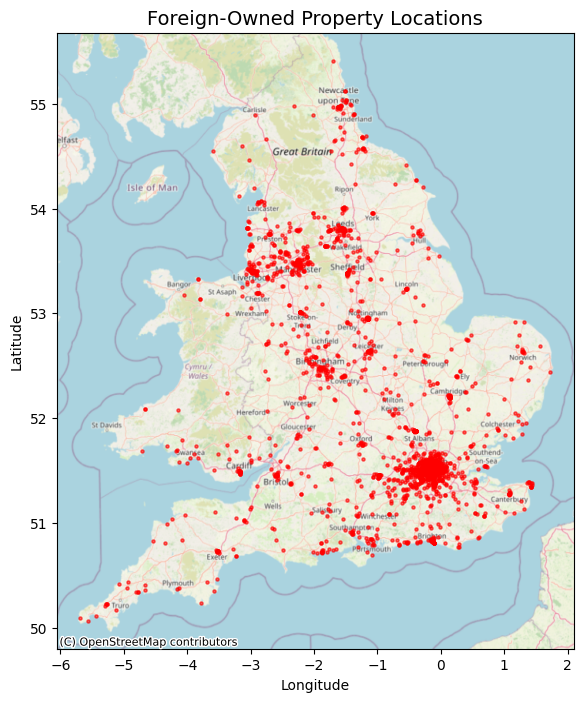

In [ ]:
!pip install contextily

import contextily as ctx

# Convert DataFrame to GeoDataFrame
gdf = gpd.GeoDataFrame(raw_df, geometry=gpd.points_from_xy(raw_df.Longitude, raw_df.Latitude), crs="EPSG:4326")

# Plot the data
fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(ax=ax, markersize=5, color="red", alpha=0.6)

# Add OpenStreetMap basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=gdf.crs)

ax.set_title("Foreign-Owned Property Locations", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Heatmap of Foreign-Owned Properties (Folium + OSM)

In [ ]:
# Create a Folium map centered on England/Wales
m = folium.Map(
    location=[52.8, -2.5],  # Approximate center of England/Wales
    zoom_start=6,
    tiles="OpenStreetMap"  # OSM base layer
)

# Add HeatMap layer
heat_data = [[row["Latitude"], row["Longitude"]] for _, row in geo_df.iterrows()]
HeatMap(heat_data, radius=15).add_to(m)

# Save or display
m.save("foreign_properties_heatmap.html")
m

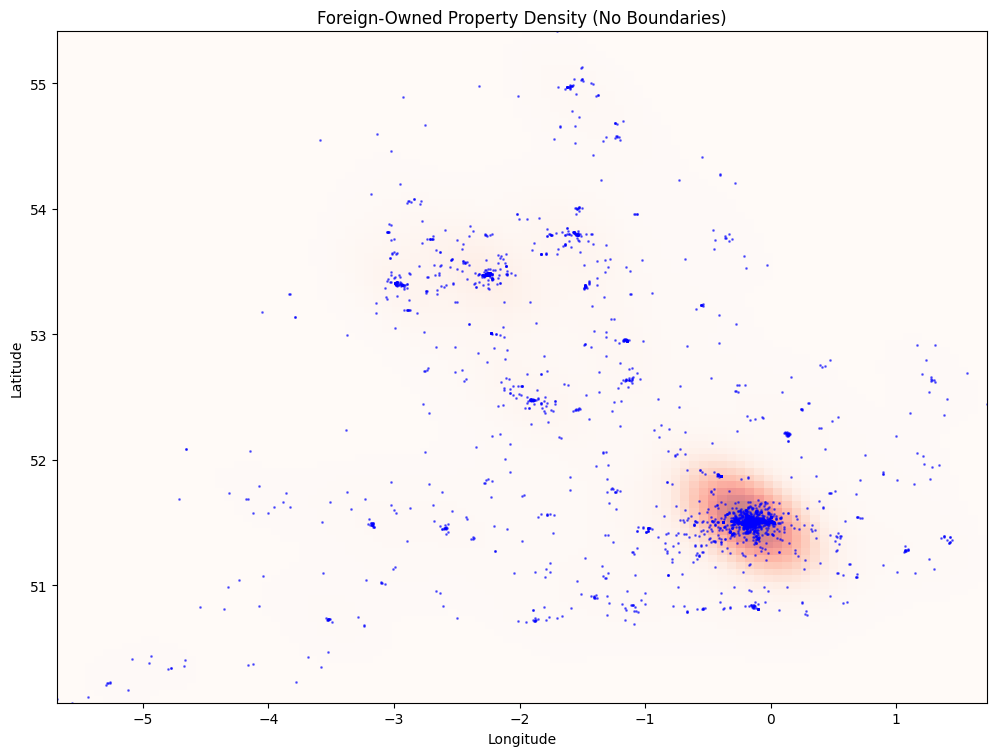

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Extract coordinates
lons = geo_df['Longitude'].values
lats = geo_df['Latitude'].values

# Create density grid
xmin, xmax = lons.min(), lons.max()
ymin, ymax = lats.min(), lats.max()
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
values = np.vstack([lons, lats])
kde = gaussian_kde(values)
density = np.reshape(kde(positions).T, xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
ax.scatter(lons, lats, s=1, alpha=0.5, c='blue')
ax.imshow(
    np.rot90(density),
    extent=[xmin, xmax, ymin, ymax],
    cmap='Reds',
    alpha=0.5
)
ax.set_title('Foreign-Owned Property Density (No Boundaries)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

## Compare urban vs. rural ownership patterns

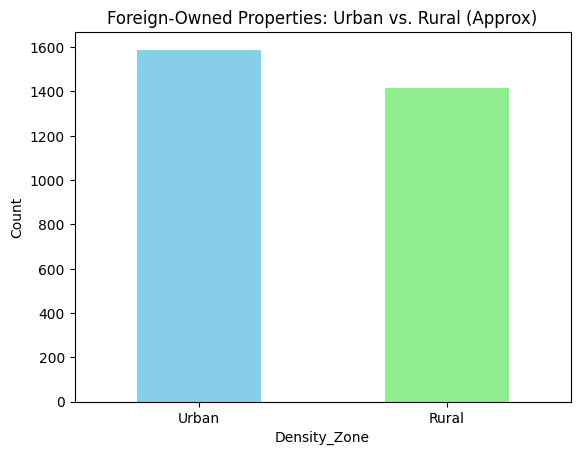

In [ ]:
# Calculate point density per area (manual approximation)
geo_df['Density_Zone'] = np.where(
    (geo_df['Longitude'].between(-0.5, 0.3)) &  # Approx London bounds - Note the change in parentheses
    (geo_df['Latitude'].between(51.3, 51.7)),
    'Urban',
    'Rural') # Removed extra parentheses

# Plot counts
geo_df['Density_Zone'].value_counts().plot(
    kind='bar',
    color=['skyblue', 'lightgreen']
)
plt.title('Foreign-Owned Properties: Urban vs. Rural (Approx)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Checking the Paid Prices of foreign properties using OSM


foreign ownership correlates with high-value areas.

In [ ]:
if 'Price_Paid' in geo_df.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(
        geo_df['Price_Paid'],
        geo_df['Latitude'],
        c=geo_df['Longitude'],
        cmap='viridis',
        alpha=0.5
    )
    plt.colorbar(label='Longitude')
    plt.title('Price vs. Location (Latitude)')
    plt.xlabel('Price Paid (£)')
    plt.ylabel('Latitude')
    plt.show()

In [ ]:
import folium
from folium.plugins import MarkerCluster

# Base map
m = folium.Map(location=[52.8, -2.5], zoom_start=6, tiles='OpenStreetMap')

# Cluster markers
marker_cluster = MarkerCluster().add_to(m)
for _, row in geo_df.iterrows():
    folium.Marker(
        [row['Latitude'], row['Longitude']],
        popup=f"Price: £{row.get('Price_Paid', 'N/A')}"
    ).add_to(marker_cluster)

m.save('cluster_map.html')
m

Output hidden; open in https://colab.research.google.com to view.